# Multi-Session Pulse Response Analysis

This notebook allows you to load, filter, and visualize pulse response clusters from multiple sessions, following the same workflow as the single-session analysis. Results from each session can be plotted side by side or in a grid for direct comparison.

## 1. Import Required Libraries
Import all necessary libraries for data loading, analysis, and visualization.

In [5]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['legend.fontsize'] = 10
plt.rcParams['figure.dpi'] = 100

## 2. Utility Function to Load Analysis Results
Define a function to load pulse analysis results from a pickle file based on session ID.

In [6]:
def load_analysis_results(session_id, results_dir='pkls'):
    pkl_path = os.path.join(results_dir, f'fast_slow_results_{session_id}.pkl')
    with open(pkl_path, 'rb') as f:
        results = pickle.load(f)
    print(f"Loaded results from {pkl_path}")
    return results

## 3. Specify Sessions and Load Data
Specify the session IDs to analyze. Data for each session will be loaded and stored in a dictionary.

In [7]:
# Example: session_ids = ['BG_031_26032025', 'BG_031_27032025']
session_ids = [
     'BG_031_26032025', 'BG_031_27022025'  # Add more session IDs as needed
]

os.chdir('E:\\python_analysis\\git_repos\\vis_detect_analysis_Apr2023')

session_data = {}
for session_id in session_ids:
    results = load_analysis_results(session_id)
    session_data[session_id] = results

Loaded results from pkls\fast_slow_results_BG_031_26032025.pkl
Loaded results from pkls\fast_slow_results_BG_031_27022025.pkl


In [12]:
session_data['BG_031_27022025'].keys()

dict_keys(['fast_pulse_times', 'slow_pulse_times', 'mean_fast', 'sem_fast', 'mean_slow', 'sem_slow', 'z_fast', 'z_slow', 'z_sem_fast', 'z_sem_slow', 't_vec', 'pre_window', 'post_window', 'dt', 'sigma_ms', 'session_id'])

## 4. Filtering and Cluster Selection Functions
Reusable functions for filtering clusters as in the single-session notebook.

In [5]:
def select_clusters(z_fast, t_vec, threshold=4.0, window=[0, 0.5]):
    window_mask = (t_vec >= window[0]) & (t_vec < window[1])
    return [clu for clu, z in z_fast.items() if np.max(z[window_mask]) > threshold]

def filter_pre_pulse(z_fast, t_vec, clusters, pre_window=[-0.05, 0], pre_activity_threshold=2.0):
    pre_mask = (t_vec >= pre_window[0]) & (t_vec < pre_window[1])
    filtered = []
    for clu in clusters:
        pre_max = np.max(np.abs(z_fast[clu][pre_mask]))
        if pre_max < pre_activity_threshold:
            filtered.append(clu)
    return filtered

def calculate_z_difference(z_fast, z_slow):
    return {clu: np.abs(z_fast[clu] - z_slow[clu]) for clu in z_fast.keys()}

def filter_post_pulse(z_diff, t_vec, clusters, post_window=[0, 0.5], responsivity_threshold=5.0):
    post_mask = (t_vec >= post_window[0]) & (t_vec < post_window[1])
    final = []
    for clu in clusters:
        max_resp = np.max(z_diff[clu][post_mask])
        if max_resp > responsivity_threshold:
            final.append(clu)
    return final

## 5. Process and Filter Clusters for Each Session
Apply the filtering steps to each session and store the filtered clusters.

In [24]:
filtered_clusters_per_session = {}
z_diff_per_session = {}
for session_id, results in session_data.items():
    z_fast = results['z_fast']
    z_slow = results['z_slow']
    t_vec = results['t_vec']
    # Step 1: Select clusters by threshold
    # selected = select_clusters(z_fast, t_vec)
    selected = select_clusters(z_fast, t_vec, threshold=3.0)
    # Step 2: Filter by pre-pulse activity
    # selected = filter_pre_pulse(z_fast, t_vec, selected)
    # Step 3: Calculate z-score difference
    z_diff = calculate_z_difference(z_fast, z_slow)
    # Step 4: Filter by post-pulse responsivity
    selected = filter_post_pulse(z_diff, t_vec, selected)
    # Optionally remove specific clusters (e.g., 295)
    if 295 in selected:
        selected.remove(295)
    filtered_clusters_per_session[session_id] = selected
    z_diff_per_session[session_id] = z_diff
    print(f"Session {session_id}: {len(selected)} clusters selected.")

Session BG_031_26032025: 18 clusters selected.
Session BG_031_27022025: 6 clusters selected.


## 6. Plot Filtered Clusters Side by Side or in a Grid
Visualize the filtered clusters for each session in a grid layout for comparison.

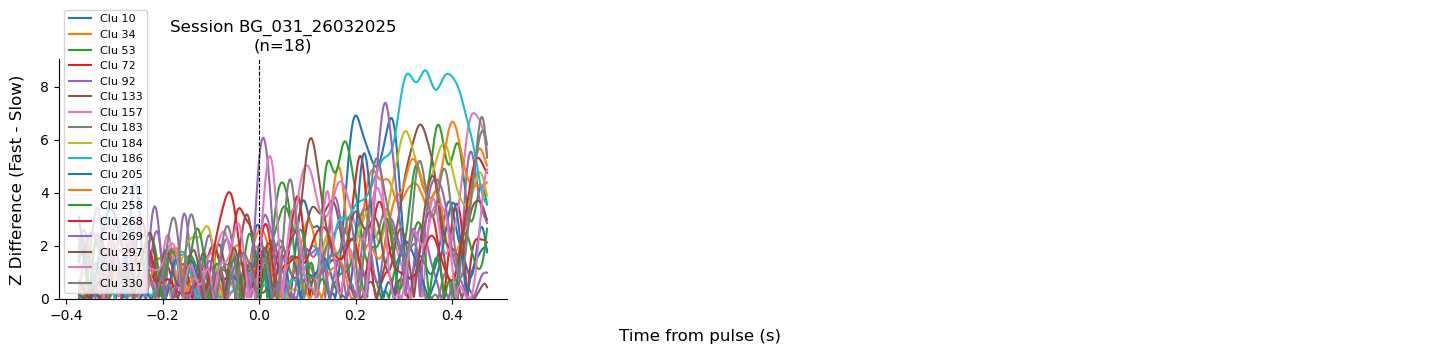

In [7]:
def plot_clusters_grid(session_data, filtered_clusters_per_session, z_diff_per_session, n_cols=3, trim_sigma=2, sigma_ms=13.3, dt=0.001):
    session_ids = list(session_data.keys())
    n_sessions = len(session_ids)
    n_rows = int(np.ceil(n_sessions / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 3.5 * n_rows), sharex=True, sharey=True)
    axes = axes.flatten()
    for idx, session_id in enumerate(session_ids):
        ax = axes[idx]
        results = session_data[session_id]
        t_vec = results['t_vec']
        clusters = filtered_clusters_per_session[session_id]
        z_diff = z_diff_per_session[session_id]
        sigma = sigma_ms / 1000 / dt
        trim = int(np.ceil(trim_sigma * sigma))
        t_vec_trim = t_vec[trim:-trim] if trim > 0 else t_vec
        for clu in clusters:
            zd = z_diff[clu][trim:-trim] if trim > 0 else z_diff[clu]
            ax.plot(t_vec_trim, zd, label=f'Clu {clu}')
        ax.axvline(0, color='k', linestyle='--', lw=0.8)
        ax.set_title(f'Session {session_id}\n(n={len(clusters)})')
        ax.set_ylim(0, None)
        if idx == 0:
            ax.legend(fontsize=8)
    for ax in axes[n_sessions:]:
        ax.axis('off')
    fig.text(0.5, 0.04, 'Time from pulse (s)', ha='center', fontsize=12)
    fig.text(0.04, 0.5, 'Z Difference (Fast - Slow)', va='center', rotation='vertical', fontsize=12)
    plt.tight_layout(rect=[0.05, 0.05, 1, 1])
    plt.show()

plot_clusters_grid(session_data, filtered_clusters_per_session, z_diff_per_session)

## 7. Plot Mean Z-Score Difference for Each Session
Visualize the mean and SEM of the z-score differences for the filtered clusters in each session.

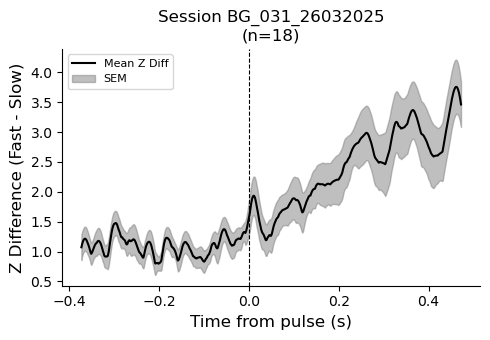

In [8]:
def calculate_mean_sem(z_diff, clusters):
    if not clusters:
        return None, None
    arr = np.stack([z_diff[clu] for clu in clusters])
    mean_diff = np.mean(arr, axis=0)
    sem_diff = np.std(arr, axis=0, ddof=1) / np.sqrt(arr.shape[0])
    return mean_diff, sem_diff

def plot_mean_sem_per_session(session_data, filtered_clusters_per_session, z_diff_per_session, trim_sigma=2, sigma_ms=13.3, dt=0.001):
    session_ids = list(session_data.keys())
    n_sessions = len(session_ids)
    fig, axes = plt.subplots(1, n_sessions, figsize=(5 * n_sessions, 3.5), sharey=True)
    if n_sessions == 1:
        axes = [axes]
    for idx, session_id in enumerate(session_ids):
        ax = axes[idx]
        results = session_data[session_id]
        t_vec = results['t_vec']
        clusters = filtered_clusters_per_session[session_id]
        z_diff = z_diff_per_session[session_id]
        sigma = sigma_ms / 1000 / dt
        trim = int(np.ceil(trim_sigma * sigma))
        t_vec_trim = t_vec[trim:-trim] if trim > 0 else t_vec
        mean_diff, sem_diff = calculate_mean_sem(z_diff, clusters)
        if mean_diff is not None:
            mean_diff_trim = mean_diff[trim:-trim] if trim > 0 else mean_diff
            sem_diff_trim = sem_diff[trim:-trim] if trim > 0 else sem_diff
            ax.plot(t_vec_trim, mean_diff_trim, color='k', label='Mean Z Diff')
            ax.fill_between(t_vec_trim, mean_diff_trim - sem_diff_trim, mean_diff_trim + sem_diff_trim, color='gray', alpha=0.5, label='SEM')
        ax.axvline(0, color='k', linestyle='--', lw=0.8)
        ax.set_title(f'Session {session_id}\n(n={len(clusters)})')
        ax.set_xlabel('Time from pulse (s)')
        if idx == 0:
            ax.set_ylabel('Z Difference (Fast - Slow)')
            ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_mean_sem_per_session(session_data, filtered_clusters_per_session, z_diff_per_session)

## 8. Next Steps
- Add or remove session IDs in the list to compare different sessions.
- Adjust filtering parameters as needed.
- Extend the notebook to include additional analyses or visualizations.

## 9. Plot Z-Scored Activity for Each Passing Cluster in Each Session
Visualize the z-scored activity (fast and slow, with SEM shading) for each passing cluster, arranged in a grid for each session (similar to the example image above).

In [9]:
def plot_passing_clusters_per_session(session_data, filtered_clusters_per_session, n_cols=5, trim_sigma=2, sigma_ms=13.3, dt=0.001):
    for session_id, results in session_data.items():
        clusters = filtered_clusters_per_session[session_id]
        if not clusters:
            print(f"No passing clusters for session {session_id}.")
            continue
        z_fast = results['z_fast']
        z_slow = results['z_slow']
        z_sem_fast = results['z_sem_fast']
        z_sem_slow = results['z_sem_slow']
        t_vec = results['t_vec']
        sigma = sigma_ms / 1000 / dt
        trim = int(np.ceil(trim_sigma * sigma))
        t_vec_trim = t_vec[trim:-trim] if trim > 0 else t_vec
        n_plot = len(clusters)
        n_rows = int(np.ceil(n_plot / n_cols))
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.5 * n_cols, 1.2 * n_rows), sharex=True, sharey=True)
        axes = axes.flatten()
        for idx, clu in enumerate(clusters):
            ax = axes[idx]
            zf = z_fast[clu][trim:-trim] if trim > 0 else z_fast[clu]
            zs = z_slow[clu][trim:-trim] if trim > 0 else z_slow[clu]
            sf = z_sem_fast[clu][trim:-trim] if trim > 0 else z_sem_fast[clu]
            ss = z_sem_slow[clu][trim:-trim] if trim > 0 else z_sem_slow[clu]
            ax.plot(t_vec_trim, zf, color='r', label='Fast')
            ax.plot(t_vec_trim, zs, color='b', label='Slow')
            ax.fill_between(t_vec_trim, zf - sf, zf + sf, color='r', alpha=0.2)
            ax.fill_between(t_vec_trim, zs - ss, zs + ss, color='b', alpha=0.2)
            ax.axvline(0, color='k', linestyle='--', lw=0.8)
            ax.set_ylim(-5, 5)
            ax.set_title(f'Clu {clu}', fontsize=9)
            if idx == 0:
                ax.legend(fontsize=8)
        for ax in axes[n_plot:]:
            ax.axis('off')
        plt.tight_layout(h_pad=0.2, w_pad=0.05)
        fig.text(0.007, 0.5, 'Z-scored activity', va='center', rotation='vertical', fontsize=12)
        fig.text(0.5, 0.007, 'Time from pulse (s)', ha='center', va='center', fontsize=12)
        plt.suptitle(f'Session {session_id} (n={n_plot} clusters)', y=1.02, fontsize=14)
        plt.show()

# plot_passing_clusters_per_session(session_data, filtered_clusters_per_session)

## 10. Plot Z-Scored Activity for All Clusters in Each Session
Visualize the z-scored activity (fast and slow, with SEM shading) for all clusters in each session, regardless of filtering.

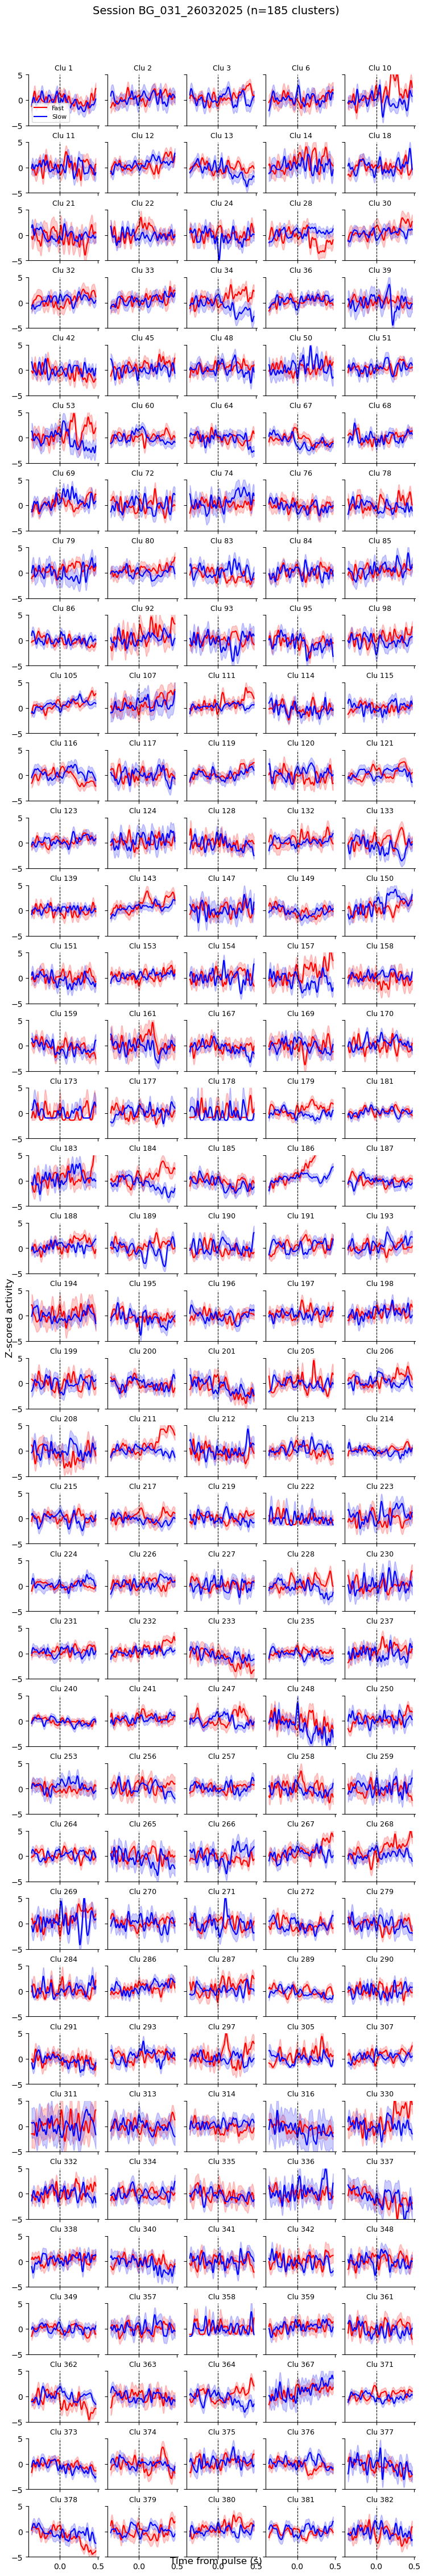

In [10]:
# Build a dictionary of all clusters per session
all_clusters_per_session = {}
for session_id, results in session_data.items():
    all_clusters_per_session[session_id] = list(results['z_fast'].keys())

plot_passing_clusters_per_session(session_data, all_clusters_per_session)

In [11]:
session_data.keys()

dict_keys(['BG_031_26032025'])

## 11. Plot Z-Scored Activity for Manually Selected Good Clusters (Session BG_031_25042025)
Visualize the z-scored activity (fast and slow, with SEM shading) for the manually selected good clusters from session BG_031_25042025.

In [12]:
good_clusters_25042025 = [610, 545, 474, 440, 362, 258, 247, 227, 221, 145, 92, 81, 54, 20, 330]
manual_clusters_per_session = {'BG_031_25042025': good_clusters_25042025}

plot_passing_clusters_per_session(session_data, manual_clusters_per_session)

KeyError: 'BG_031_26032025'

## 12. Feature Extraction and Similarity-Based Filtering for Cluster Selection
Extract features from the manually selected good clusters and use them to find similar clusters automatically.

Selected 294 clusters similar to the good set (threshold=4.60).


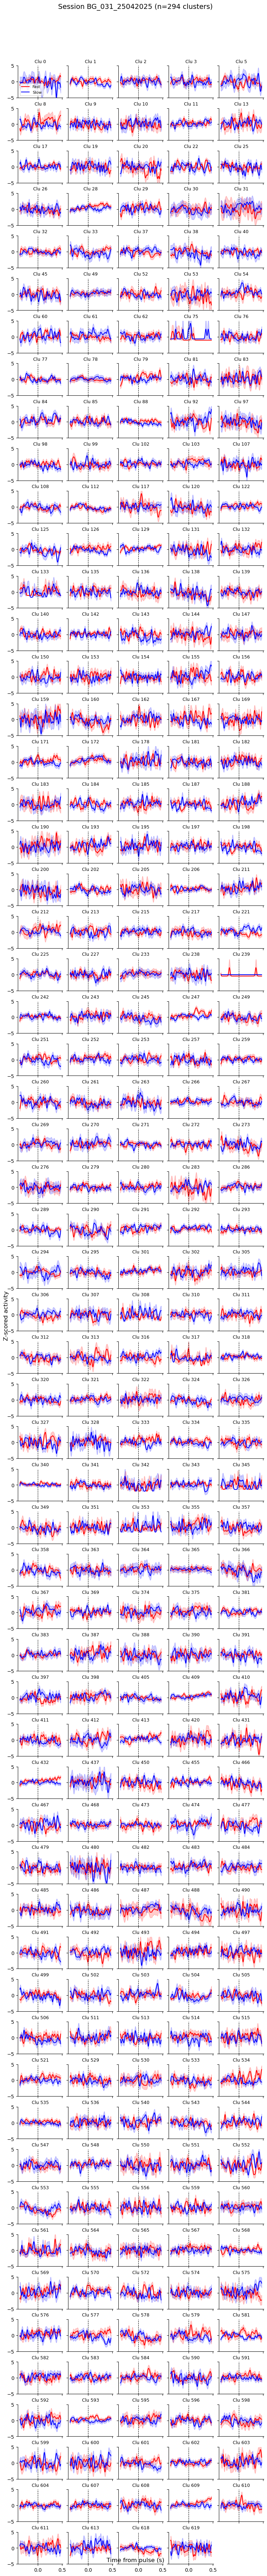

In [19]:
from scipy.stats import zscore
from scipy.spatial.distance import cdist

def extract_features(z_fast, z_slow, t_vec, clusters, window=[0, 0.5]):
    """
    Extracts features from clusters: peak, time-to-peak, mean, std, and area in a post-pulse window for both fast and slow.
    Returns a feature matrix (n_clusters, n_features).
    """
    features = []
    window_mask = (t_vec >= window[0]) & (t_vec < window[1])
    for clu in clusters:
        zf = z_fast[clu][window_mask]
        zs = z_slow[clu][window_mask]
        # Features: max, time-to-max, mean, std, area for fast and slow
        f = [
            np.max(zf),
            np.argmax(zf),
            np.mean(zf),
            np.std(zf),
            np.trapz(zf, t_vec[window_mask]),
            np.max(zs),
            np.argmax(zs),
            np.mean(zs),
            np.std(zs),
            np.trapz(zs, t_vec[window_mask]),
        ]
        features.append(f)
    return np.array(features)

# 1. Extract features from good clusters
session_id = 'BG_031_25042025'
results = session_data[session_id]
z_fast = results['z_fast']
z_slow = results['z_slow']
t_vec = results['t_vec']
good_clusters = good_clusters_25042025
features_good = extract_features(z_fast, z_slow, t_vec, good_clusters)

# 2. Extract features from all clusters
all_clusters = list(z_fast.keys())
features_all = extract_features(z_fast, z_slow, t_vec, all_clusters)

# 3. Z-score features for fair comparison
features_good_z = zscore(features_good, axis=0)
features_all_z = zscore(features_all, axis=0)

# 4. Compute similarity (Euclidean distance) from each cluster to the mean of good clusters
mean_good = np.mean(features_good_z, axis=0)
dists = cdist(features_all_z, mean_good[None, :], metric='euclidean').flatten()

# 5. Select clusters with distance below a threshold (e.g., within 1.5 std of good clusters)
threshold = np.mean(dists) + 1.5 * np.std(dists)
similar_clusters = [clu for clu, d in zip(all_clusters, dists) if d < threshold]
print(f"Selected {len(similar_clusters)} clusters similar to the good set (threshold={threshold:.2f}).")

# 6. Plot the similar clusters
similar_clusters_per_session = {session_id: similar_clusters}
plot_passing_clusters_per_session(session_data, similar_clusters_per_session)

## 13. Improved Feature Extraction and Filtering: Pre-pulse Quietness & Post-pulse Responsivity
This cell implements a more targeted filter:
- Ensures pre-pulse activity is low ("quiet" baseline)
- Requires fast and/or slow signals to exceed a confidence threshold for a minimum duration after the pulse

In [13]:
def filter_clusters_advanced(z_fast, z_slow, z_sem_fast, z_sem_slow, t_vec, pre_window=[-0.05, 0], post_window=[0, 0.5], 
                            pre_thresh=6.0, post_z_thresh=3.0, min_duration_ms=50, dt=0.001):
    """
    Returns clusters that:
    - Have max(abs(z)) < pre_thresh in pre_window (quiet baseline)
    - Have fast or slow z-score > post_z_thresh for at least min_duration_ms in post_window
    - Also checks that SEM is not too large during the detected response
    """
    pre_mask = (t_vec >= pre_window[0]) & (t_vec < pre_window[1])
    post_mask = (t_vec >= post_window[0]) & (t_vec < post_window[1])
    min_samples = int(np.ceil(min_duration_ms / 1000 / dt))
    passing = []
    for clu in z_fast:
        # Pre-pulse quietness
        pre_max = np.max(np.abs(z_fast[clu][pre_mask]))
        pre_max_slow = np.max(np.abs(z_slow[clu][pre_mask]))
        if pre_max >= pre_thresh or pre_max_slow >= pre_thresh:
            continue
        # Post-pulse responsivity (fast or slow)
        zf_post = z_fast[clu][post_mask]
        zs_post = z_slow[clu][post_mask]
        sf_post = z_sem_fast[clu][post_mask]
        ss_post = z_sem_slow[clu][post_mask]
        # Find contiguous regions above threshold
        above_fast = zf_post > post_z_thresh
        above_slow = zs_post > post_z_thresh
        # Use run-length encoding to find if any region is long enough
        def has_long_enough(above):
            count = 0
            for v in above:
                if v:
                    count += 1
                    if count >= min_samples:
                        return True
                else:
                    count = 0
            return False
        if has_long_enough(above_fast) or has_long_enough(above_slow):
            # Optionally: check SEM is not too large during response
            # (e.g., mean SEM in above region < 2)
            if has_long_enough(above_fast):
                sem_ok = np.mean(sf_post[above_fast]) < 2 if np.any(above_fast) else True
            else:
                sem_ok = np.mean(ss_post[above_slow]) < 2 if np.any(above_slow) else True
            if sem_ok:
                passing.append(clu)
    return passing

# Apply the advanced filter to the session
session_id = 'BG_031_25042025'
results = session_data[session_id]
z_fast = results['z_fast']
z_slow = results['z_slow']
z_sem_fast = results['z_sem_fast']
z_sem_slow = results['z_sem_slow']
t_vec = results['t_vec']

advanced_clusters = filter_clusters_advanced(
    z_fast, z_slow, z_sem_fast, z_sem_slow, t_vec,
    pre_window=[-0.05, 0], post_window=[0, 0.5],
    pre_thresh=2.0, post_z_thresh=3.0, min_duration_ms=50, dt=0.001
)
print(f"Advanced filter: {len(advanced_clusters)} clusters found.")

advanced_clusters_per_session = {session_id: advanced_clusters}
plot_passing_clusters_per_session(session_data, advanced_clusters_per_session)

KeyError: 'BG_031_25042025'

In [14]:
def filter_clusters_relaxed(z_fast, z_slow, z_sem_fast, z_sem_slow, t_vec, pre_window=[-0.05, 0], post_window=[0, 0.5], 
                            pre_thresh=3.0, post_z_thresh=2.0, min_duration_ms=20, dt=0.001):
    pre_mask = (t_vec >= pre_window[0]) & (t_vec < pre_window[1])
    post_mask = (t_vec >= post_window[0]) & (t_vec < post_window[1])
    min_samples = int(np.ceil(min_duration_ms / 1000 / dt))
    passing = []
    for clu in z_fast:
        pre_max = np.max(np.abs(z_fast[clu][pre_mask]))
        pre_max_slow = np.max(np.abs(z_slow[clu][pre_mask]))
        if pre_max >= pre_thresh or pre_max_slow >= pre_thresh:
            continue
        zf_post = z_fast[clu][post_mask]
        zs_post = z_slow[clu][post_mask]
        # No SEM check for now
        above_fast = zf_post > post_z_thresh
        above_slow = zs_post > post_z_thresh
        def has_long_enough(above):
            count = 0
            for v in above:
                if v:
                    count += 1
                    if count >= min_samples:
                        return True
                else:
                    count = 0
            return False
        if has_long_enough(above_fast) or has_long_enough(above_slow):
            passing.append(clu)
    return passing

# Apply the relaxed filter
session_id = 'BG_031_25042025'
results = session_data[session_id]
z_fast = results['z_fast']
z_slow = results['z_slow']
z_sem_fast = results['z_sem_fast']
z_sem_slow = results['z_sem_slow']
t_vec = results['t_vec']

relaxed_clusters = filter_clusters_relaxed(
    z_fast, z_slow, z_sem_fast, z_sem_slow, t_vec,
    pre_window=[-0.20, 0], post_window=[0, 0.5],
    pre_thresh=1.9, post_z_thresh=3.5, min_duration_ms=15, dt=0.001
)
print(f"Relaxed filter: {len(relaxed_clusters)} clusters found.")

relaxed_clusters_per_session = {session_id: relaxed_clusters}
plot_passing_clusters_per_session(session_data, relaxed_clusters_per_session)

KeyError: 'BG_031_25042025'

In [15]:
def plot_mean_relaxed_clusters_per_session(session_data, relaxed_clusters_per_session, z_sem_fast, z_sem_slow, trim_sigma=2, sigma_ms=13.3, dt=0.001):
    session_ids = list(relaxed_clusters_per_session.keys())
    n_sessions = len(session_ids)
    fig, axes = plt.subplots(1, n_sessions, figsize=(5 * n_sessions, 3.5), sharey=True)
    if n_sessions == 1:
        axes = [axes]
    for idx, session_id in enumerate(session_ids):
        ax = axes[idx]
        clusters = relaxed_clusters_per_session[session_id]
        if not clusters:
            ax.set_title(f'Session {session_id}\n(n=0)')
            continue
        results = session_data[session_id]
        t_vec = results['t_vec']
        z_fast = results['z_fast']
        z_slow = results['z_slow']
        # Stack arrays for mean/sem
        arr_fast = np.stack([z_fast[clu] for clu in clusters])
        arr_slow = np.stack([z_slow[clu] for clu in clusters])
        arr_sem_fast = np.stack([z_sem_fast[clu] for clu in clusters])
        arr_sem_slow = np.stack([z_sem_slow[clu] for clu in clusters])
        sigma = sigma_ms / 1000 / dt
        trim = int(np.ceil(trim_sigma * sigma))
        t_vec_trim = t_vec[trim:-trim] if trim > 0 else t_vec
        mean_fast = np.mean(arr_fast, axis=0)[trim:-trim] if trim > 0 else np.mean(arr_fast, axis=0)
        mean_slow = np.mean(arr_slow, axis=0)[trim:-trim] if trim > 0 else np.mean(arr_slow, axis=0)
        sem_fast = np.sqrt(np.mean(arr_sem_fast**2, axis=0))[trim:-trim] if trim > 0 else np.sqrt(np.mean(arr_sem_fast**2, axis=0))
        sem_slow = np.sqrt(np.mean(arr_sem_slow**2, axis=0))[trim:-trim] if trim > 0 else np.sqrt(np.mean(arr_sem_slow**2, axis=0))
        ax.plot(t_vec_trim, mean_fast, color='r', label='Fast')
        ax.plot(t_vec_trim, mean_slow, color='b', label='Slow')
        ax.fill_between(t_vec_trim, mean_fast - sem_fast, mean_fast + sem_fast, color='r', alpha=0.2)
        ax.fill_between(t_vec_trim, mean_slow - sem_slow, mean_slow + sem_slow, color='b', alpha=0.2)
        ax.axvline(0, color='k', linestyle='--', lw=0.8)
        ax.set_title(f'Session {session_id}\n(n={len(clusters)})')
        ax.set_xlabel('Time from pulse (s)')
        if idx == 0:
            ax.set_ylabel('Z-scored activity')
            ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()

plot_mean_relaxed_clusters_per_session(session_data, relaxed_clusters_per_session, z_sem_fast, z_sem_slow)

NameError: name 'relaxed_clusters_per_session' is not defined

## 14. Unsupervised Clustering of Fast/Slow Responses in Post-Pulse Window
Cluster the fast and slow responses in the post-pulse window using unsupervised methods (e.g., KMeans) to identify groups of similar response profiles. This can help reveal common features among clusters.

c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
c:\Users\Ben\anaconda3\envs\myenv\lib\site-packages\sklearn\cluster\_kmeans.py:1440: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


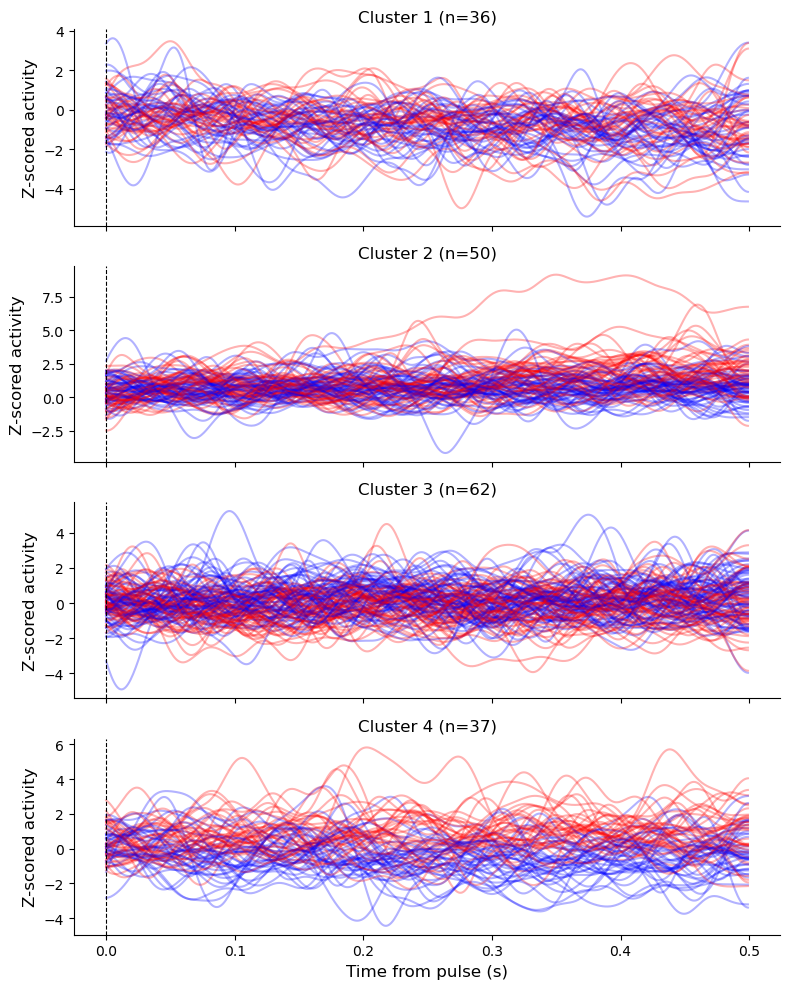

Cluster 1: [1, 13, 64, 67, 76, 95, 114, 128, 149, 159, 167, 169, 185, 187, 195, 200, 201, 233, 240, 248, 258, 265, 272, 279, 289, 291, 313, 316, 335, 337, 340, 362, 373, 377, 378, 382]
Cluster 2: [2, 3, 12, 14, 30, 32, 33, 45, 50, 51, 69, 74, 85, 92, 105, 107, 111, 119, 121, 123, 124, 132, 143, 150, 153, 183, 186, 188, 191, 197, 198, 206, 211, 226, 231, 232, 241, 250, 267, 268, 269, 286, 287, 293, 307, 330, 359, 367, 375, 380]
Cluster 3: [6, 18, 21, 24, 28, 36, 42, 68, 72, 83, 84, 86, 115, 116, 117, 120, 139, 147, 154, 158, 170, 173, 177, 178, 181, 190, 193, 194, 196, 199, 205, 208, 212, 213, 219, 222, 223, 224, 227, 230, 253, 257, 259, 264, 266, 271, 284, 290, 311, 314, 334, 336, 338, 341, 349, 357, 358, 363, 374, 376, 379, 381]
Cluster 4: [10, 11, 22, 34, 39, 48, 53, 60, 78, 79, 80, 93, 98, 133, 151, 157, 161, 179, 184, 189, 214, 215, 217, 228, 235, 237, 247, 256, 270, 297, 305, 332, 342, 348, 361, 364, 371]


In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Parameters
session_id = 'BG_031_26032025'
results = session_data[session_id]
z_fast = results['z_fast']
z_slow = results['z_slow']
t_vec = results['t_vec']

# Define post-pulse window
post_window = [0, 0.5]
post_mask = (t_vec >= post_window[0]) & (t_vec < post_window[1])

# Build feature matrix: concatenate fast and slow traces in the window for each cluster
all_clusters = list(z_fast.keys())
X = np.stack([np.concatenate([z_fast[clu][post_mask], z_slow[clu][post_mask]]) for clu in all_clusters])

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Choose number of clusters (try 3-6, can adjust)
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
labels = kmeans.fit_predict(X_scaled)

# Plot clusters
fig, axes = plt.subplots(n_clusters, 1, figsize=(8, 2.5 * n_clusters), sharex=True)
if n_clusters == 1:
    axes = [axes]
for i in range(n_clusters):
    ax = axes[i]
    idxs = np.where(labels == i)[0]
    for idx in idxs:
        fast = z_fast[all_clusters[idx]][post_mask]
        slow = z_slow[all_clusters[idx]][post_mask]
        ax.plot(t_vec[post_mask], fast, color='r', alpha=0.3)
        ax.plot(t_vec[post_mask], slow, color='b', alpha=0.3)
    ax.set_title(f'Cluster {i+1} (n={len(idxs)})')
    ax.axvline(0, color='k', linestyle='--', lw=0.8)
    ax.set_ylabel('Z-scored activity')
axes[-1].set_xlabel('Time from pulse (s)')
plt.tight_layout()
plt.show()

# Optionally: print cluster membership for each cluster id
for i in range(n_clusters):
    idxs = np.where(labels == i)[0]
    print(f"Cluster {i+1}: {[all_clusters[idx] for idx in idxs]}")

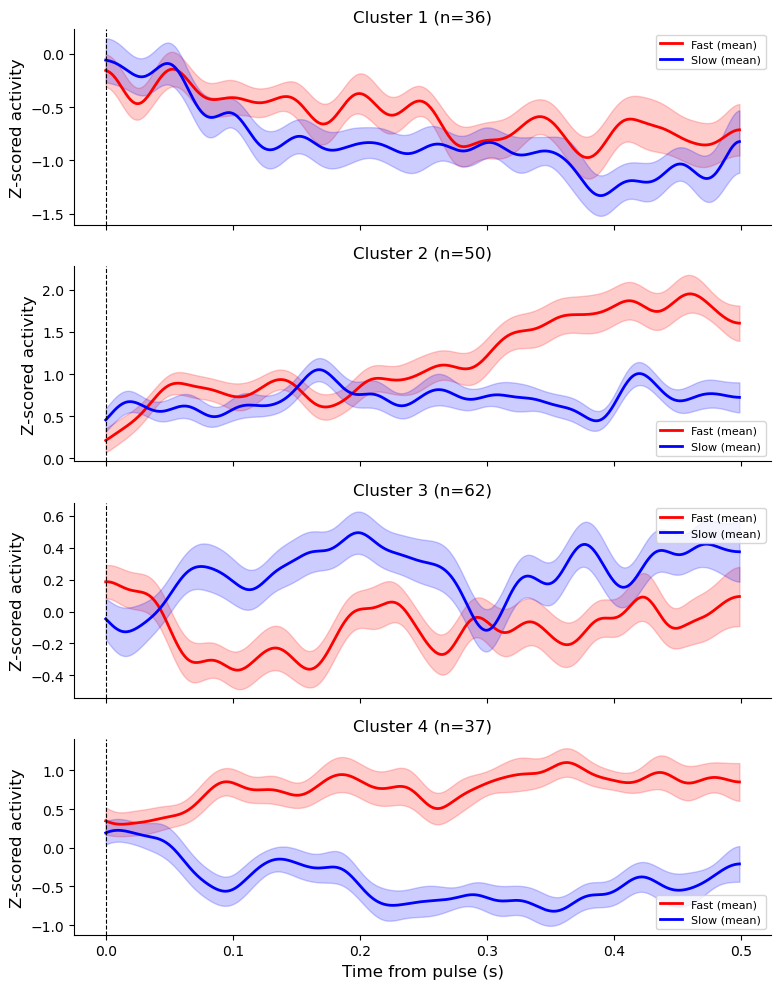

In [8]:
# Plot mean fast/slow traces for each KMeans cluster, using the same colors as the individual traces above

cluster_colors = ['C0', 'C1', 'C2', 'C3', 'C4', 'C5']  # matplotlib default cycle, enough for up to 6 clusters

fig, axes = plt.subplots(n_clusters, 1, figsize=(8, 2.5 * n_clusters), sharex=True)
if n_clusters == 1:
    axes = [axes]
for i in range(n_clusters):
    ax = axes[i]
    idxs = np.where(labels == i)[0]
    # Stack fast and slow for mean/sem
    fast_mat = np.stack([z_fast[all_clusters[idx]][post_mask] for idx in idxs])
    slow_mat = np.stack([z_slow[all_clusters[idx]][post_mask] for idx in idxs])
    mean_fast = fast_mat.mean(axis=0)
    mean_slow = slow_mat.mean(axis=0)
    sem_fast = fast_mat.std(axis=0, ddof=1) / np.sqrt(fast_mat.shape[0])
    sem_slow = slow_mat.std(axis=0, ddof=1) / np.sqrt(slow_mat.shape[0])
    # Plot mean with SEM shading
    ax.plot(t_vec[post_mask], mean_fast, color='r', lw=2, label='Fast (mean)')
    ax.fill_between(t_vec[post_mask], mean_fast - sem_fast, mean_fast + sem_fast, color='r', alpha=0.2)
    ax.plot(t_vec[post_mask], mean_slow, color='b', lw=2, label='Slow (mean)')
    ax.fill_between(t_vec[post_mask], mean_slow - sem_slow, mean_slow + sem_slow, color='b', alpha=0.2)
    ax.set_title(f'Cluster {i+1} (n={len(idxs)})')
    ax.axvline(0, color='k', linestyle='--', lw=0.8)
    ax.set_ylabel('Z-scored activity')
    ax.legend(fontsize=8)
axes[-1].set_xlabel('Time from pulse (s)')
plt.tight_layout()
plt.show()

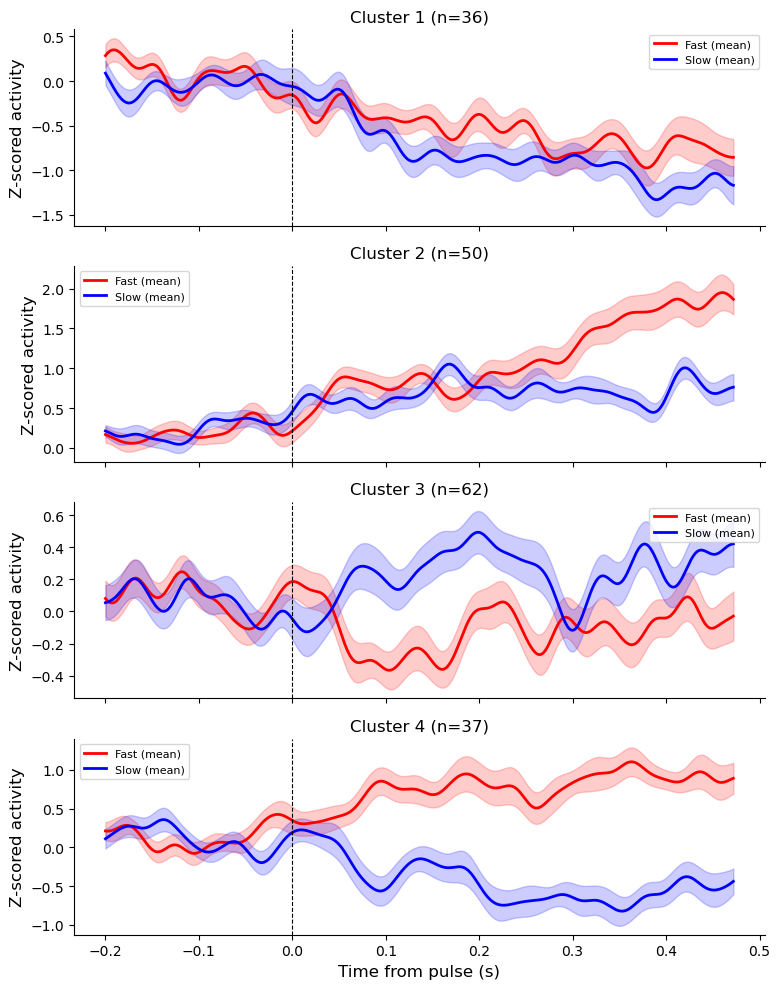

In [17]:
# Plot mean fast/slow traces for each KMeans cluster, showing more of the pre-pulse window (after artifact trim)

# Parameters for trimming artifact and showing more pre-pulse
trim_sigma = 2
sigma_ms = 13.3
dt = 0.001
pre_window = [-0.2, 0.5]  # Show from -200 ms to +500 ms

sigma = sigma_ms / 1000 / dt
trim = int(np.ceil(trim_sigma * sigma))

# Find indices for the extended window (after artifact trim)
t_vec_full = t_vec[trim:-trim] if trim > 0 else t_vec
pre_mask_full = (t_vec_full >= pre_window[0]) & (t_vec_full < pre_window[1])

fig, axes = plt.subplots(n_clusters, 1, figsize=(8, 2.5 * n_clusters), sharex=True)
if n_clusters == 1:
    axes = [axes]
for i in range(n_clusters):
    ax = axes[i]
    idxs = np.where(labels == i)[0]
    # Stack fast and slow for mean/sem, using the full trimmed window
    fast_mat = np.stack([z_fast[all_clusters[idx]][trim:-trim][pre_mask_full] for idx in idxs])
    slow_mat = np.stack([z_slow[all_clusters[idx]][trim:-trim][pre_mask_full] for idx in idxs])
    t_vec_plot = t_vec_full[pre_mask_full]
    mean_fast = fast_mat.mean(axis=0)
    mean_slow = slow_mat.mean(axis=0)
    sem_fast = fast_mat.std(axis=0, ddof=1) / np.sqrt(fast_mat.shape[0])
    sem_slow = slow_mat.std(axis=0, ddof=1) / np.sqrt(slow_mat.shape[0])
    # Plot mean with SEM shading
    ax.plot(t_vec_plot, mean_fast, color='r', lw=2, label='Fast (mean)')
    ax.fill_between(t_vec_plot, mean_fast - sem_fast, mean_fast + sem_fast, color='r', alpha=0.2)
    ax.plot(t_vec_plot, mean_slow, color='b', lw=2, label='Slow (mean)')
    ax.fill_between(t_vec_plot, mean_slow - sem_slow, mean_slow + sem_slow, color='b', alpha=0.2)
    ax.axvline(0, color='k', linestyle='--', lw=0.8)
    ax.set_title(f'Cluster {i+1} (n={len(idxs)})')
    ax.set_ylabel('Z-scored activity')
    ax.legend(fontsize=8)
axes[-1].set_xlabel('Time from pulse (s)')
plt.tight_layout()
plt.show()

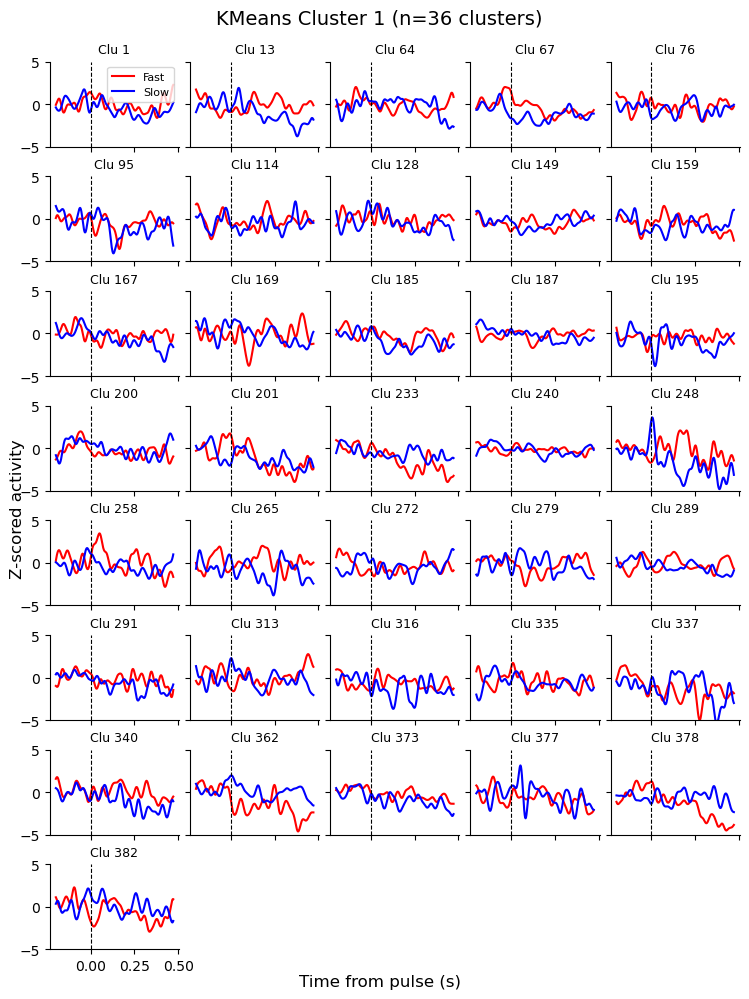

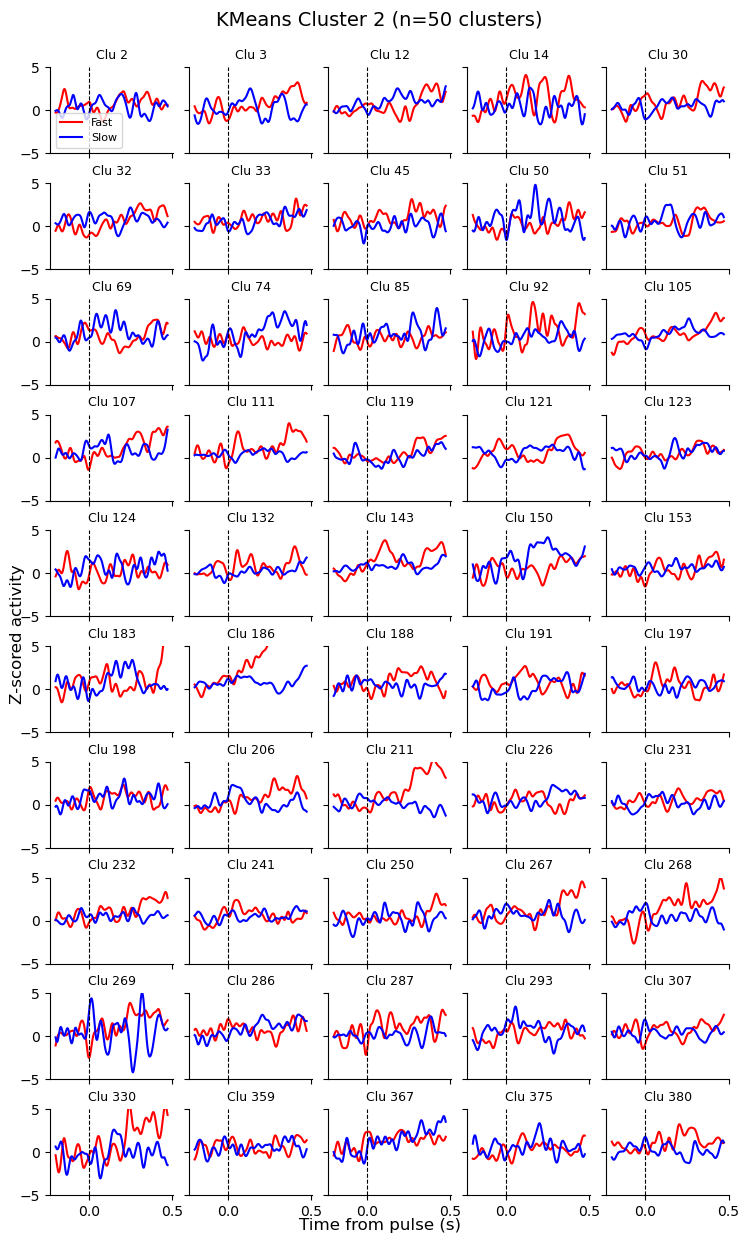

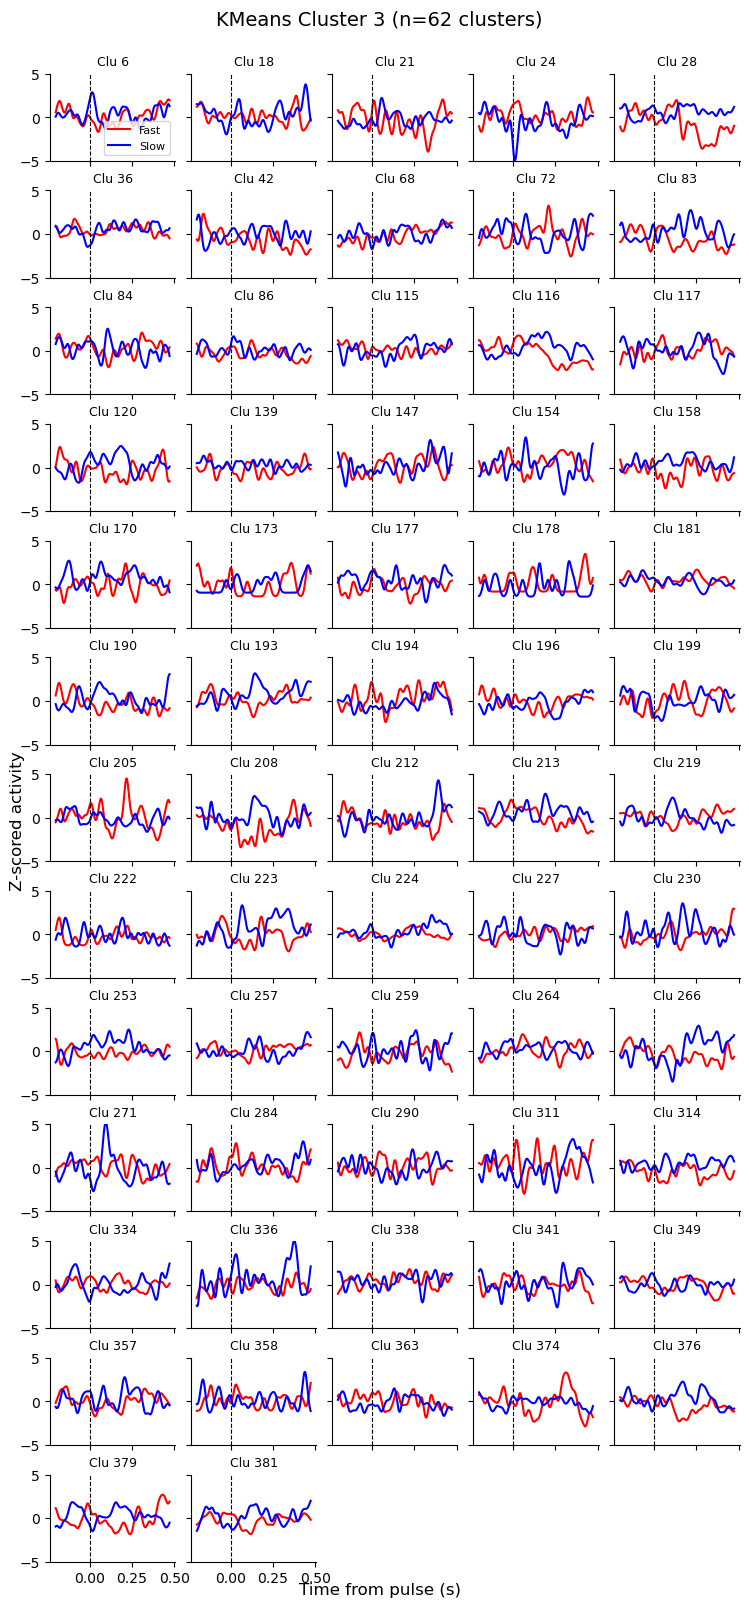

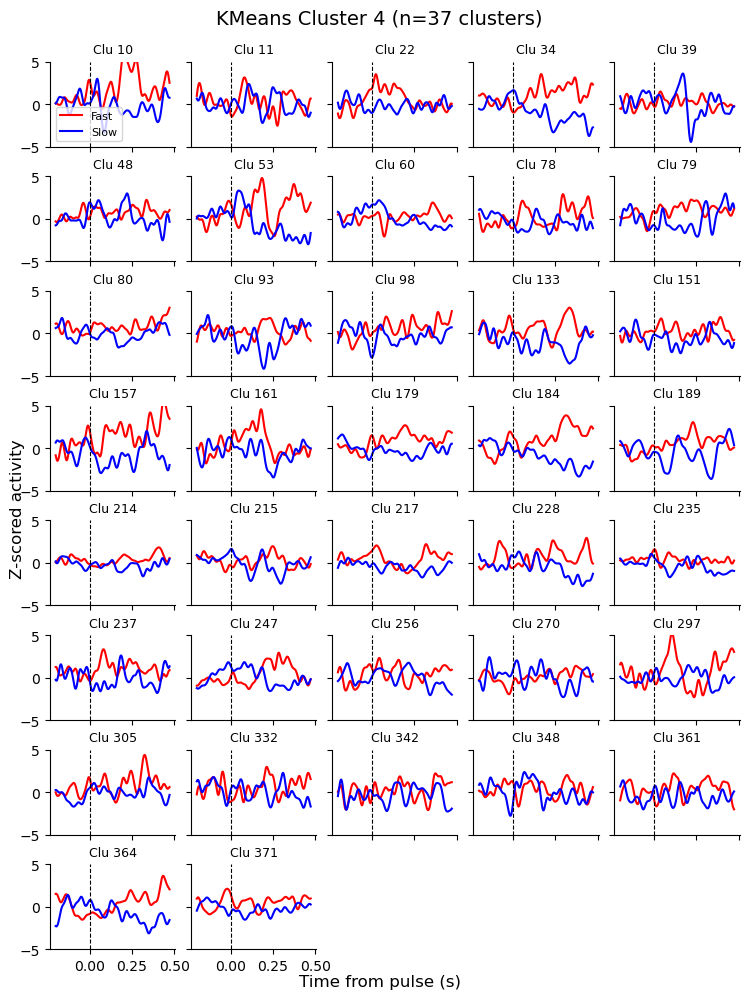

In [11]:
# Plot individual fast/slow traces for each KMeans cluster, showing more of the pre-pulse window (after artifact trim), in a grid

# Parameters for trimming artifact and showing more pre-pulse
trim_sigma = 2
sigma_ms = 13.3
dt = 0.001
pre_window = [-0.2, 0.5]  # Show from -200 ms to +500 ms

sigma = sigma_ms / 1000 / dt
trim = int(np.ceil(trim_sigma * sigma))

# Find indices for the extended window (after artifact trim)
t_vec_full = t_vec[trim:-trim] if trim > 0 else t_vec
pre_mask_full = (t_vec_full >= pre_window[0]) & (t_vec_full < pre_window[1])
t_vec_plot = t_vec_full[pre_mask_full]

n_cols = 5  # Number of columns in the grid for each cluster

for i in range(n_clusters):
    idxs = np.where(labels == i)[0]
    n_plot = len(idxs)
    n_rows = int(np.ceil(n_plot / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.5 * n_cols, 1.2 * n_rows), sharex=True, sharey=True)
    axes = axes.flatten()
    for j, idx in enumerate(idxs):
        ax = axes[j]
        fast = z_fast[all_clusters[idx]][trim:-trim][pre_mask_full]
        slow = z_slow[all_clusters[idx]][trim:-trim][pre_mask_full]
        ax.plot(t_vec_plot, fast, color='r', label='Fast')
        ax.plot(t_vec_plot, slow, color='b', label='Slow')
        ax.axvline(0, color='k', linestyle='--', lw=0.8)
        ax.set_ylim(-5, 5)
        ax.set_title(f'Clu {all_clusters[idx]}', fontsize=9)
        if j == 0:
            ax.legend(fontsize=8)
    for ax in axes[n_plot:]:
        ax.axis('off')
    plt.tight_layout(h_pad=0.2, w_pad=0.05)
    fig.text(0.007, 0.5, 'Z-scored activity', va='center', rotation='vertical', fontsize=12)
    fig.text(0.5, 0.007, 'Time from pulse (s)', ha='center', va='center', fontsize=12)
    plt.suptitle(f'KMeans Cluster {i+1} (n={n_plot} clusters)', y=1.02, fontsize=14)
    plt.show()

In [3]:
# --- First Lick Alignment and Comparison of TF-Responsive vs Non-Responsive Clusters ---


def get_first_lick_times(behav_data):
    """
    Extracts the time of the first lick for each trial from behav_data['trials_data_exp'].
    Returns a list of first lick times (None if no lick in trial).
    """
    first_lick_times = []
    for trial in behav_data['trials_data_exp']:
        licks = trial.get('lick_times', [])
        if isinstance(licks, np.ndarray):
            licks = licks.tolist()
        if licks:
            first_lick_times.append(licks[0])
        else:
            first_lick_times.append(None)
    return first_lick_times


def plot_clusters_aligned_to_event(session_data, session_id, clusters, event_times, t_vec, window=[-0.5, 0.5], n_cols=5):
    """
    Plots z-scored activity for given clusters aligned to specified event times (e.g., first lick).
    """
    results = session_data[session_id]
    z_fast = results['z_fast']
    z_slow = results['z_slow']
    t_vec = results['t_vec']
    n_plot = len(clusters)
    n_rows = int(np.ceil(n_plot / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(1.5 * n_cols, 1.2 * n_rows), sharex=True, sharey=True)
    axes = axes.flatten()
    for idx, clu in enumerate(clusters):
        ax = axes[idx]
        # For each trial, align to event and average
        aligned_fast = []
        aligned_slow = []
        for et in event_times:
            if et is None:
                continue
            # Find closest index in t_vec to event time
            event_idx = np.argmin(np.abs(t_vec - et))
            # Extract window around event
            win_mask = (t_vec >= et + window[0]) & (t_vec < et + window[1])
            if np.sum(win_mask) == 0:
                continue
            aligned_fast.append(z_fast[clu][win_mask])
            aligned_slow.append(z_slow[clu][win_mask])
        if aligned_fast:
            mean_fast = np.mean(np.stack(aligned_fast), axis=0)
            mean_slow = np.mean(np.stack(aligned_slow), axis=0)
            t_plot = np.linspace(window[0], window[1], len(mean_fast))
            ax.plot(t_plot, mean_fast, color='r', label='Fast')
            ax.plot(t_plot, mean_slow, color='b', label='Slow')
        ax.axvline(0, color='k', linestyle='--', lw=0.8)
        ax.set_ylim(-5, 5)
        ax.set_title(f'Clu {clu}', fontsize=9)
        if idx == 0:
            ax.legend(fontsize=8)
    for ax in axes[n_plot:]:
        ax.axis('off')
    plt.tight_layout(h_pad=0.2, w_pad=0.05)
    fig.text(0.007, 0.5, 'Z-scored activity', va='center', rotation='vertical', fontsize=12)
    fig.text(0.5, 0.007, 'Time from event (s)', ha='center', va='center', fontsize=12)
    plt.suptitle(f'Clusters aligned to event (n={n_plot})', y=1.02, fontsize=14)
    plt.show()


# Example usage:


# session_id = 'BG_031_26032025'


# behav_data = session_data[session_id]['behav_data']


# first_lick_times = get_first_lick_times(behav_data)


# tf_clusters = filtered_clusters_per_session[session_id]


# all_clusters = list(session_data[session_id]['z_fast'].keys())


# non_tf_clusters = [clu for clu in all_clusters if clu not in tf_clusters]


# plot_clusters_aligned_to_event(session_data, session_id, tf_clusters, first_lick_times, session_data[session_id]['t_vec'])


# plot_clusters_aligned_to_event(session_data, session_id, non_tf_clusters, first_lick_times, session_data[session_id]['t_vec'])

In [4]:
# Check if 'lick_times' exists in your trial data
session_id = list(session_data.keys())[0]
behav_data = session_data[session_id]['behav_data']
trial = behav_data['trials_data_exp'][0]
print(trial.keys())

NameError: name 'session_data' is not defined